# Calculation of coherent elastic neutrino-electron scattering E$\nu$ES

In this notebook we outline how to generate E$\nu$ES rate. First we show how to do it for the SM and then for non-zero NSI parameters. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from snudd import config
from snudd.targets import Electron      # the elctron target class object
from snudd.binding import binding_xe, binding_ar    # dataclass of binding energy data for xenon and argon
from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
from snudd.models  import GeneralNSI    # Generic NSI model
from snudd.targets import Nucleus       # Still need a nucleus to be declared

Setting up the target of the DD experiment:

In [3]:
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 
Ar_nucleus = Nucleus(18, 40, mass=39.96238312 * config.u) # only do one isotope for this example 

## SM E$\nu$ES scattering rate 

 We generate an instance of the SM (in terms of zero NSI) and compute and plot the theoretical (i.e. without including any experimental effects) E$\nu$ES rate in Xe.

In [4]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

SM_eta = 0
SM_phi = 0

sm_model = GeneralNSI(SM_matrix, SM_eta, SM_phi)

Update the nucleus object with the NSI model, i.e. the SM in this case.

In [5]:
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

Ar_electron = Electron(Ar_nucleus, binding_ar) 
Ar_electron.update_model(sm_model)
Ar_electron.prepare_density()

In [6]:
E_Rs = np.logspace(-3, 2, 1000) / 1e6  # Recoil Energy in GeV

In [7]:
sm_spec_xe = Xe_electron.spectrum(E_Rs) 
sm_spec_ar = Ar_electron.spectrum(E_Rs) 

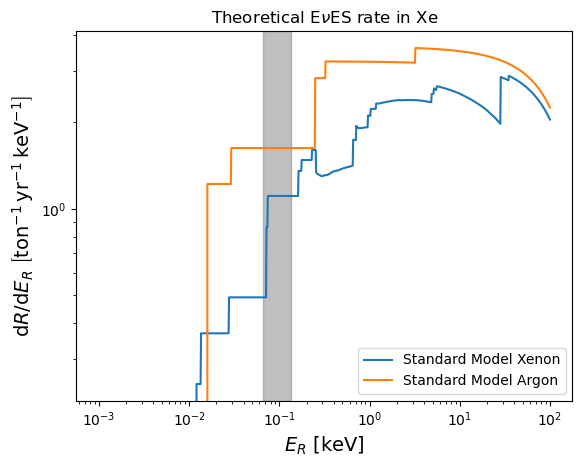

In [8]:
plt.loglog(E_Rs*1e6, abs(sm_spec_xe), label="Standard Model Xenon")
plt.loglog(E_Rs*1e6, abs(sm_spec_ar), label="Standard Model Argon")


plt.legend()
plt.title(r"Theoretical E$\nu$ES rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)


plt.axvspan(66e-3, 133e-3, color='gray', alpha=0.5, label='PDX energy range')
#plt.xlim(xmin=1e-1, xmax=1e2)
#plt.ylim(ymax=5e0, ymin=5e-1)

In [9]:
E_Rs_PDx = np.geomspace(66e-3, 133e-3, 100) / 1e6  # Recoil Energy in GeV

In [10]:
sm_spec_xePDx = Xe_electron.spectrum(E_Rs_PDx) 


In [11]:
np.trapezoid(sm_spec_xePDx, x=E_Rs_PDx) * 1.04 # Integrate the spectrum to get the total rate

np.complex128(7.30483224008742e-08+8.048639406035457e-26j)

In [12]:
np.trapezoid(sm_spec_xe, x=E_Rs) * 1.04 # Integrate the spectrum to get the total rate

np.complex128(0.0002540695660213627+2.865741354483636e-22j)

In [13]:
sm_spec_xePDx

array([0.49218445+5.41798782e-19j, 0.49218363+5.41781265e-19j,
       0.49218279+5.41762878e-19j, 0.49218196+5.41744258e-19j,
       0.49218111+5.41737744e-19j, 0.49218026+5.41734756e-19j,
       0.49217941+5.41730048e-19j, 0.49217854+5.41722455e-19j,
       0.49217768+5.41715514e-19j, 0.4921768 +5.41714591e-19j,
       0.49217592+5.41718891e-19j, 0.49217503+5.41725632e-19j,
       0.86130474+9.48043144e-19j, 0.86130317+9.48072015e-19j,
       0.86130158+9.48096341e-19j, 0.86129998+9.48117768e-19j,
       1.10738363+1.21904992e-18j, 1.10738154+1.21907728e-18j,
       1.10737945+1.21908624e-18j, 1.10737734+1.21909115e-18j,
       1.10737521+1.21910573e-18j, 1.10737307+1.21911242e-18j,
       1.10737091+1.21911306e-18j, 1.10736873+1.21910677e-18j,
       1.10736655+1.21910717e-18j, 1.10736434+1.21911780e-18j,
       1.10736212+1.21913188e-18j, 1.10735989+1.21914352e-18j,
       1.10735764+1.21917299e-18j, 1.10735537+1.21917834e-18j,
       1.10735309+1.21917563e-18j, 1.10735079+1.2191640

## NSI E$\nu$ES scattering rate 

Now do the same for a non-zero NSI $\varepsilon_{e\mu}=0.1$ coupling with electrons ($\varphi=-\pi/2$).

In [14]:
NSI_matrix = np.array([[0.0, 0.1, 0.0],
                       [0.1, 0.0, 0.0],
                       [0.0, 0.0, 0.0]])

NSI_eta = 0.0
NSI_phi = -np.pi/2

NSI_model = GeneralNSI(NSI_matrix, NSI_eta, NSI_phi)

Update the nucleus object with the new NSI model and compute the new spectrum.

In [15]:
Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling)
Xe_electron.update_model(NSI_model)
Xe_electron.prepare_density()

In [16]:
NSI_spec = Xe_electron.spectrum(E_Rs)

Plotting the SM and NSI spectra.

(0.5, 5.0)

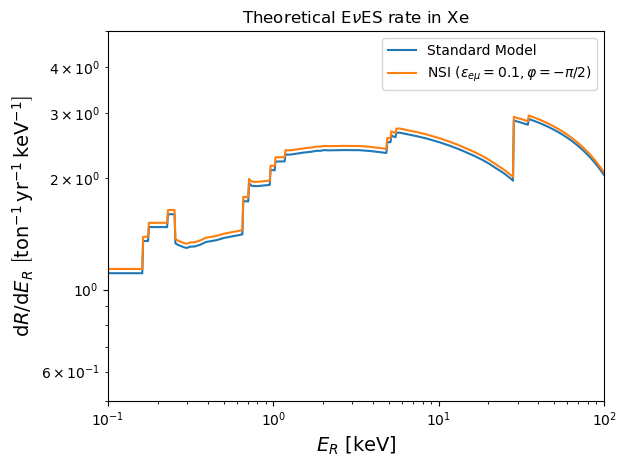

In [17]:
plt.loglog(E_Rs*1e6, abs(sm_spec_xe), label="Standard Model")
plt.loglog(E_Rs*1e6, abs(NSI_spec), label=r"NSI ($\varepsilon_{e\mu}=0.1, \varphi=-\pi/2$)")

plt.legend()
plt.title(r"Theoretical E$\nu$ES rate in Xe")
plt.ylabel(r'${\rm d}R/{\rm d}E_R\,\,\left[{\rm ton}^{-1}\,{\rm yr}^{-1}\,{\rm keV}^{-1}\right]$', size=14)
plt.xlabel(r'$E_{R}\,\,\left[{\rm keV}\right]$', size=14)

plt.xlim(xmin=1e-1, xmax=1e2)
plt.ylim(ymax=5e0, ymin=5e-1)